# ReGRID model analysis

### Demand map / Renewable energy map

Last update: 12 February, 2026

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import geopandas as gpd
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

In [11]:
# Case setting
TERM = '1y' # Analysis term: 1y=Yearly
STEP = 6 # Timestep(h)
VER = 'v8' # Model version
YEAR = 2050 # Target year
BOUNDARY = 'japan' # Spatial boundary
NETWORK = '1741' # TSN:Transmission, '1741':Municipality
PATHWAY = 'C1' # Socioeconomic and emission pathway: C1:1.5C, C7:below 4C
POTENTIAL_AVAILABILITY = 100 # Uniform availability of renewable energy(%)
POTENTIAL_CASE = 'high' # Renewable energy potential assumptions ('base':HPA, 'low':PA+OECM, 'mid':Enhanced, 'high':FullProtect)
COST_CASE = 'moderate' # Cost assumption

In [12]:
# Data for analysis

output_path = 'output/analysis'

# Region list
region_list = pd.read_csv('input/region.csv', index_col='code', dtype={'code':str, 'DSN':str, 'pref_code':str})

REGION = region_list.index.to_list() # All nodes
SUBSTATION = pd.read_csv('input/region_substation.csv', index_col=0, dtype={'region':str})['region'].to_list() # Substation nodes
NODE = [r for r in REGION if r not in SUBSTATION] # Terminal nodes
AREA = region_list['DSN'].copy() # Distribution area
REGION06 = pd.Series(data=[f"{r:>6}".replace(' ','_') for r in REGION], index=REGION) # Region list (6 digit code)
SPREGION = {}

# # Coordinate
city_coord = pd.read_csv('input/analysis/position.csv', index_col=0, dtype={'code':str})

# Scenario data
scenario_data = pd.read_csv('input/scenarios.csv', index_col=0, dtype={'year':str})
scenario = scenario_data[scenario_data['category'] == PATHWAY] # Energy demand and emissions pathway

# Population scenario
population = pd.read_csv('input/population.csv', index_col='code', dtype={'code':str})
regional_population_growth = population[str(YEAR)] / population['2020'] # Population growth rate
national_population_growth = sum(population[str(YEAR)]) / sum(population['2020']) # Population growth rate

# Electricity demand
regional_current_demand = pd.read_csv('input/%sh/elect.csv' % (STEP), index_col=0)
national_current_demand = regional_current_demand.sum().sum()
national_future_demand = scenario['Final Energy|Electricity'][str(YEAR)] * 1000000 #TWh -> MWh
regional_future_demand = regional_current_demand * (regional_population_growth / national_population_growth) * (national_future_demand / national_current_demand)
regional_future_demand = regional_future_demand * (national_future_demand / regional_future_demand.sum().sum())
regional_future_demand = regional_future_demand.loc[:,REGION]

# Technology dataset (Cost, Efficiency, etc.)
P = pd.read_csv(f'input/technology/technology_{PATHWAY}.csv', index_col=0)
P = P[(P['year'] == YEAR) & (P['scenario'] == COST_CASE)]

# Renewable energy temporal profiles
profile = {}
profile["solar"] = pd.read_csv('input/%sh/solar_2019.csv' % (STEP), index_col=0)
profile["onwin"] = pd.read_csv('input/%sh/onwind_2019.csv' % (STEP), index_col=0)
profile["of-fx"] = pd.read_csv('input/%sh/ofwind_2019_fixed.csv' % (STEP), index_col=0)
profile["of-fl"] = pd.read_csv('input/%sh/ofwind_2019_float.csv' % (STEP), index_col=0)
profile["river"] = pd.read_csv('input/%sh/river_2019.csv' % (STEP), index_col=0)
profile["geoth"] = pd.read_csv('input/%sh/geothermal_2019.csv' % (STEP), index_col=0)
profile["hydro"] = pd.read_csv('input/%sh/hydro_2019.csv' % (STEP), index_col=0)

# Annual capacity factor for renewables
CF_annual = {}
for res in profile.keys():
    CF_annual[res] = (profile[res] / STEP).mean()

In [13]:
# Chart paramter
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['xtick.direction'] = 'out'
plt.rcParams['ytick.direction'] = 'out'
plt.rcParams['xtick.major.width'] = 0.3
plt.rcParams['ytick.major.width'] = 0.3
plt.rcParams['xtick.major.size'] = 2.5
plt.rcParams['ytick.major.size'] = 2.5
plt.rcParams['xtick.minor.width'] = 0.3
plt.rcParams['ytick.minor.width'] = 0.3
plt.rcParams['xtick.minor.size'] = 2
plt.rcParams['ytick.minor.size'] = 2
plt.rcParams['font.size'] = 7
plt.rcParams['xtick.labelsize'] = 7
plt.rcParams['ytick.labelsize'] = 7
plt.rcParams['axes.linewidth'] = 0

MAX_WIDTH = 180 / 25.4 # inch in 180mm

In [ ]:
# Grid map

def map_plot(map_data, map_label, cmap, c_error, map_min, map_max, threshold, map_area, map_title, anot=None):

    # Setup grid map
    fig = plt.figure(figsize=(MAX_WIDTH*0.45, MAX_WIDTH*0.5), dpi=300)
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Geographical coverage [W,E,S,N]
    area_coord = [126.6, 147.0, 25.6, 45.9]
    map_width = area_coord[1]-area_coord[0]
    map_height = area_coord[3]-area_coord[2]
        
    # National boundary
    japan_shapes = list(gpd.read_file("input/analysis/boundary/Japan.gpkg").geometry)
    ax.add_geometries(japan_shapes, ccrs.PlateCarree(), edgecolor=(0.1,0.1,0.1,1), facecolor=(0,0,0,0), linewidth = 0.1, zorder=2)

    # Municipal boundary
    municipal_shapes = list(gpd.read_file("input/analysis/boundary/1741municipalities.gpkg").geometry)

    # Colormap
    if map_max == "max":
        color_max = map_data.max()
    else:
        color_max = map_max

    if map_min == "min":
        color_min = map_data.min()
    else:
        color_min = map_min

    if threshold == 'log':
        norm = mcolors.LogNorm(vmin=color_min, vmax=color_max)
    elif threshold is not None:
        norm = mcolors.TwoSlopeNorm(vmin=color_min, vcenter=threshold, vmax=color_max)
    else:
        norm = mcolors.Normalize(vmin=color_min, vmax=color_max)
        
    for n, city in enumerate(municipal_shapes):
        value = max(min(map_data.iloc[n], color_max), color_min)
        polygon_color = cmap(norm(value))
        ax.add_geometries(city, ccrs.PlateCarree(), edgecolor=(0.8,0.8,0.8,1), facecolor=polygon_color, linewidth = 0, zorder=1)

    # Colorbar
    heat_map = ax.imshow([[color_min],[color_max]], cmap=cmap, norm=norm)
    cbar = fig.colorbar(heat_map, shrink=0.7, aspect=50, pad=0.02, orientation='horizontal')
    cbar.set_label(map_label, fontsize=5, labelpad=3)
    cbar.ax.tick_params(labelsize=5, pad=2)

    # Gridlines
    gl = ax.gridlines(draw_labels=True, linewidth=0.1, color='gray', alpha=0.6, linestyle='--')
    gl.top_labels = True
    gl.right_labels = False
    gl.bottom_labels = False
    gl.left_labels = True
    gl.xlabel_style = {'fontsize': 5, 'color': "gray"}
    gl.ylabel_style = {'fontsize': 5, 'color': "gray"}
    gl.xformatter = LONGITUDE_FORMATTER #°E
    gl.yformatter = LATITUDE_FORMATTER #°N
    gl.xpadding = 1
    gl.ypadding = 1

    if anot is not None:
        ax.annotate(anot, xy=(0.5, 0.02), xycoords="axes fraction", ha="center", fontsize=5)

    # Draw
    ax.set_extent(area_coord, crs=ccrs.PlateCarree())
    plt.axis('off')
    if map_title is not None:
        plt.savefig(f"{output_path}/{map_title}.png", bbox_inches='tight', pad_inches=0, transparent=False, dpi=3000)
        # plt.savefig(f"{output_path}/{map_title}.pdf", bbox_inches='tight', pad_inches=0, transparent=False, dpi=300)
    plt.show()
    plt.clf()

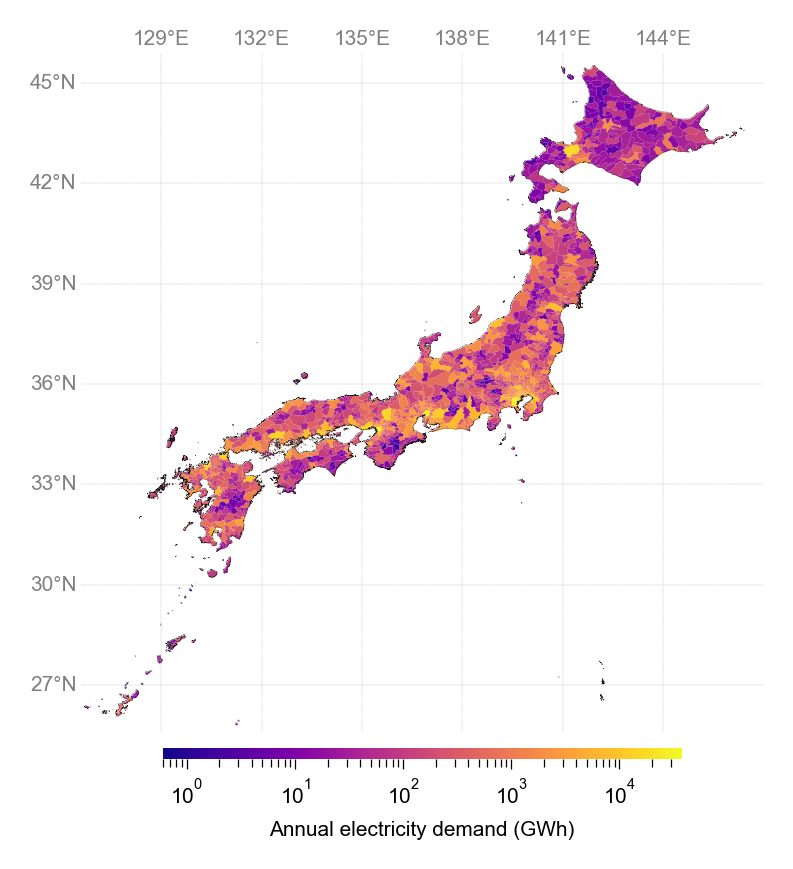

<Figure size 640x480 with 0 Axes>

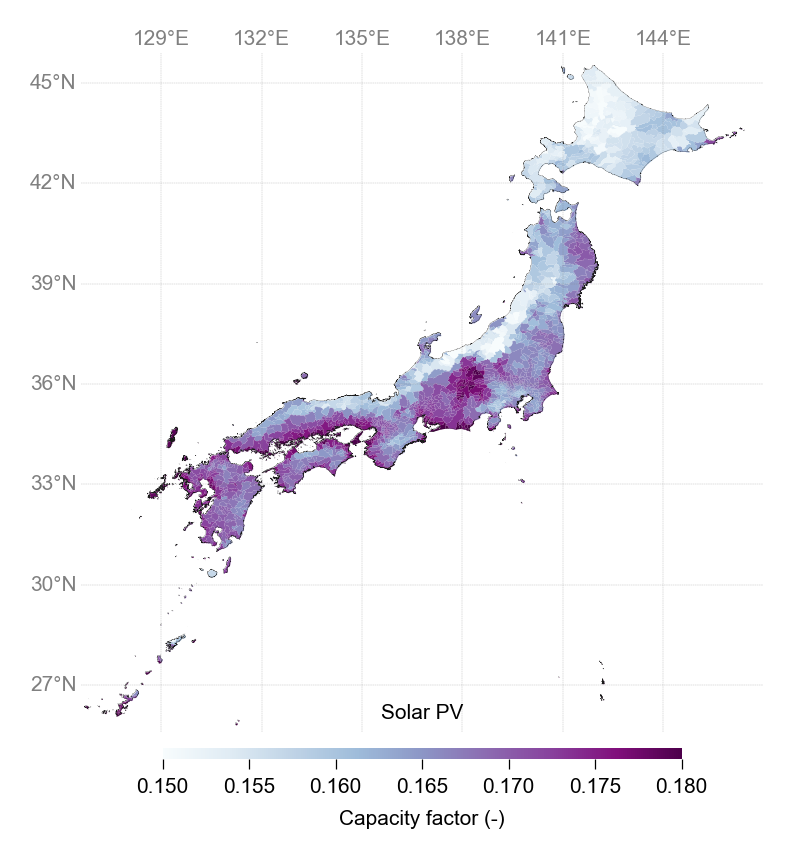

<Figure size 640x480 with 0 Axes>

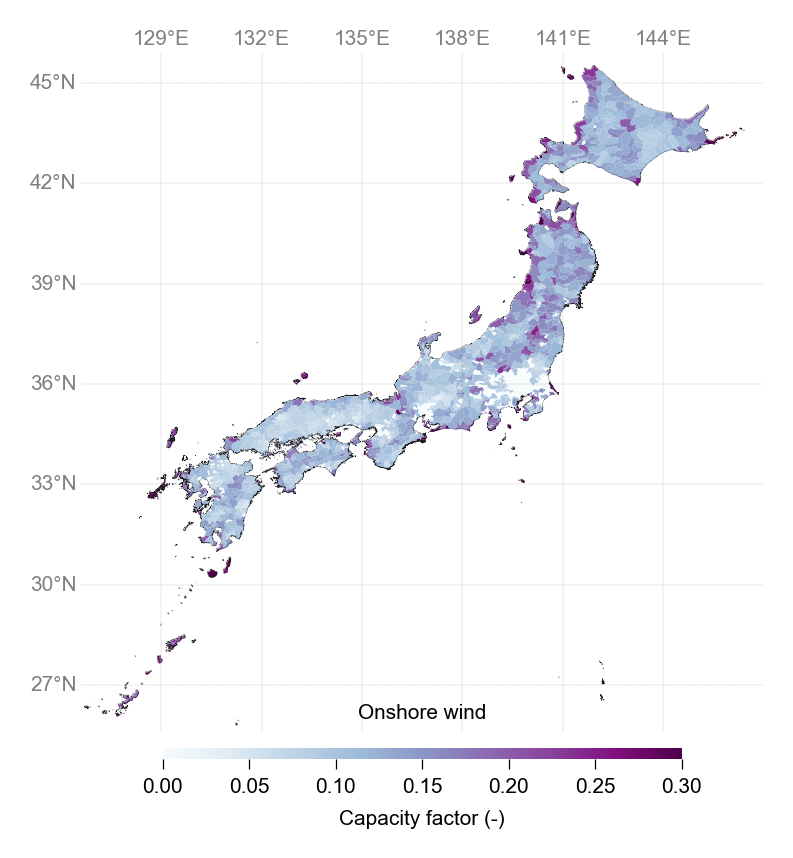

<Figure size 640x480 with 0 Axes>

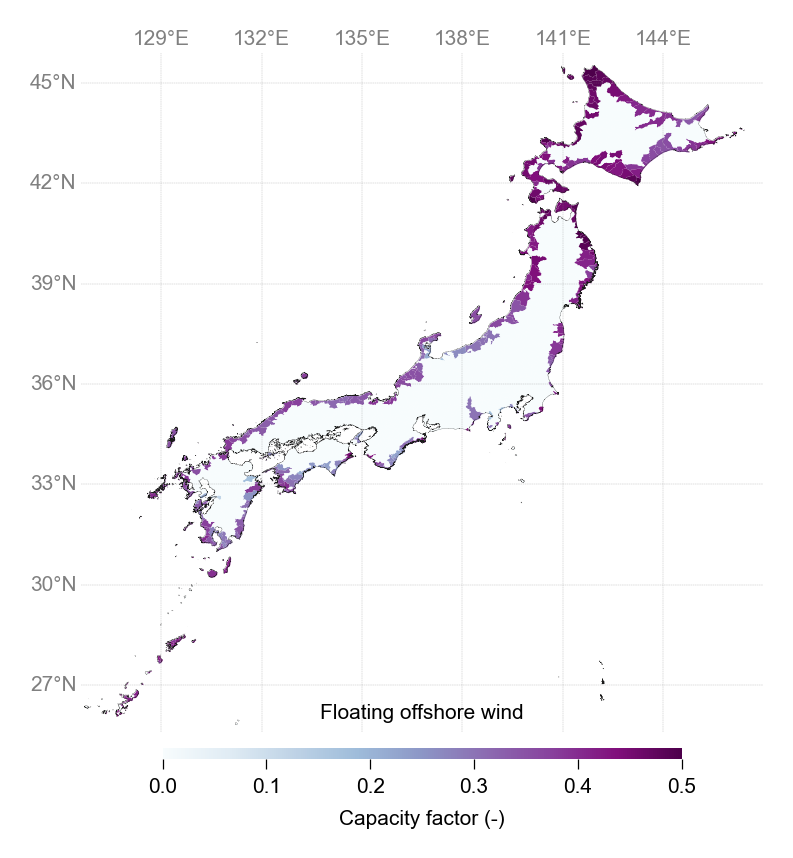

<Figure size 640x480 with 0 Axes>

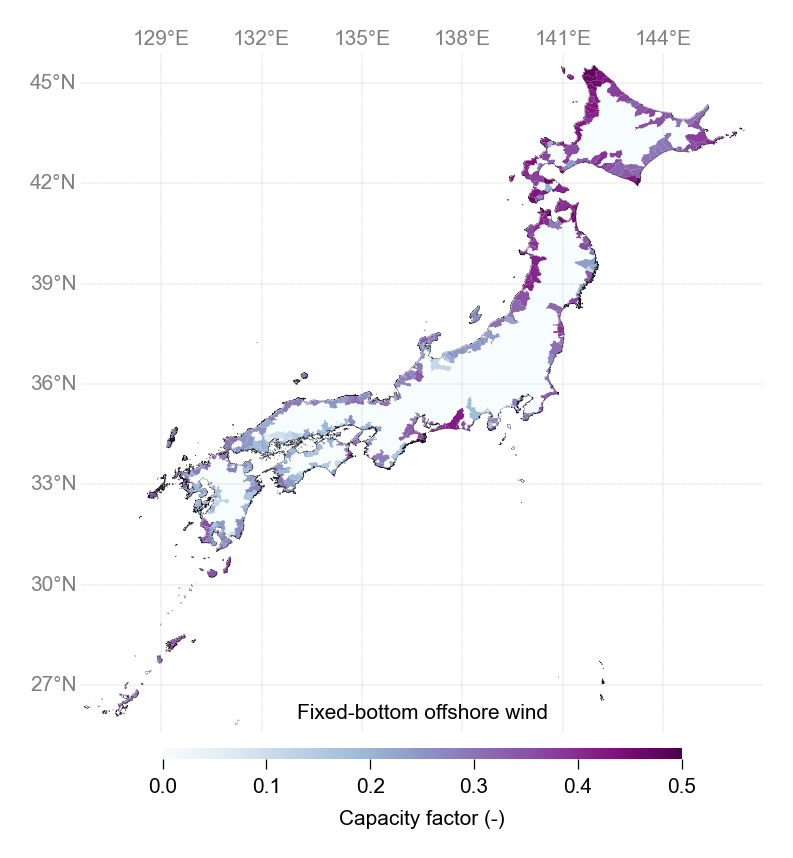

<Figure size 640x480 with 0 Axes>

In [15]:
# Electricity demand
demand_GWh = regional_future_demand.sum()/1000
map_plot(demand_GWh, 'Annual electricity demand (GWh)', cm.plasma, '#ddd', 'min', 'max', 'log', 'japan', 'map_demand_log')
# map_plot(demand_GWh/1000, 'Annual electricity demand (TWh)', cm.plasma, '#ddd', 0, 18, None, 'japan', 'map_demand')

# Capacity factor of VRE
range_min = {'solar':0.15, 'onwin':0, 'of-fl':0, 'of-fx':0}
range_max = {'solar':0.18, 'onwin':0.3, 'of-fl':0.5, 'of-fx':0.5}
for res in ['solar', 'onwin', 'of-fl', 'of-fx']:
    map_plot(CF_annual[res], 'Capacity factor (-)', cm.BuPu, '#ddd', range_min[res], range_max[res], None, 'japan', f'map_CF_{res}', P['name'][res])